# Potências e Raízes

**Módulo:** 02 – Logaritmos

**Pré-requisitos:** Python básico e a introdução a potenciação e radiciação de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (`00_introducao_python.ipynb`)

**Objetivos de aprendizagem:**
- Operar com potências de expoente natural e inteiro negativo aplicando as propriedades operatórias de forma justificada, não apenas mecânica.
- Calcular e simplificar raízes enésimas, reconhecendo quando elas existem em ℝ, e racionalizar denominadores.
- Converter entre potências de expoente racional e radicais, entendendo por que a base precisa ser positiva nesse caso.
- Compreender, de forma intuitiva, como se define potência de expoente irracional e real — preparando terreno para a função exponencial.

**Tempo estimado:** 80 a 100 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/02_logaritmos/0201a_potencias_e_raizes.ipynb)

📖 **Leitura complementar geral do notebook:** [Exponenciação](https://pt.wikipedia.org/wiki/Exponencia%C3%A7%C3%A3o) · [Radiciação](https://pt.wikipedia.org/wiki/Radicia%C3%A7%C3%A3o) · [Número irracional](https://pt.wikipedia.org/wiki/N%C3%BAmero_irracional)

## O tabuleiro de xadrez que ninguém consegue pagar

Reza a lenda que Sessa ibn Daher, o inventor do jogo de xadrez, foi chamado por um rei da Índia para escolher sua própria recompensa. Sessa pediu algo aparentemente modesto: grãos de trigo colocados sobre o tabuleiro, dobrando a quantidade a cada casa — 1 grão na primeira casa, 2 na segunda, 4 na terceira, 8 na quarta, e assim por diante, até a 64ª e última casa.

O rei achou o pedido humilde demais e prontamente aceitou — sem fazer as contas antes.

**Antes de continuar, arrisque um palpite:** quantos grãos de trigo seriam necessários ao todo, somando as 64 casas? Um punhado? Um caminhão? Guarde seu palpite — ao final do primeiro bloco deste notebook você mesmo vai calcular esse número com Python, usando exatamente a ferramenta que estamos prestes a estudar: **potências**.

📖 **Leitura complementar:** [Sessa ibn Daher](https://pt.wikipedia.org/wiki/Sessa_ibn_Daher)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def raiz_real(radicando: float, indice: int) -> float:
    '''Calcula a raiz enésima real de radicando, quando ela existe.

    Para índice par, exige radicando >= 0 (senão retorna NaN, sinalizando
    que a raiz não existe em R). Para índice ímpar, aceita qualquer
    radicando real, inclusive negativo, preservando o sinal.
    '''
    if radicando < 0:
        if indice % 2 == 0:
            return float("nan")
        return -((-radicando) ** (1 / indice))
    return radicando ** (1 / indice)

## 1. Potência de Expoente Natural

Multiplicar o mesmo número por ele mesmo várias vezes aparece o tempo todo — em juros, em crescimento populacional, em armazenamento de dados. Em vez de escrever a multiplicação por extenso, usamos potências.

📌 **Definição formal:** dado a ∈ ℝ e n ∈ ℕ, com n ≥ 1, definimos

$$a^n = \underbrace{a \cdot a \cdot \ldots \cdot a}_{n \text{ fatores}}$$

Chamamos a de **base** e n de **expoente**. Por convenção, definimos também **a⁰ = 1** para todo a ≠ 0 — a justificativa vem logo na pergunta de checagem abaixo.

**Propriedades operatórias** (a, b ∈ ℝ*, m, n ∈ ℕ):

| Propriedade | Enunciado |
|---|---|
| Produto de potências de mesma base | aᵐ · aⁿ = aᵐ⁺ⁿ |
| Quociente de potências de mesma base | aᵐ / aⁿ = aᵐ⁻ⁿ |
| Potência de potência | (aᵐ)ⁿ = aᵐ·ⁿ |
| Distributiva sobre o produto | (a · b)ⁿ = aⁿ · bⁿ |
| Distributiva sobre o quociente | (a / b)ⁿ = aⁿ / bⁿ |

Nenhuma dessas propriedades é uma regra decorada — todas são consequência direta de **contar fatores**. Por exemplo, aᵐ · aⁿ junta m fatores de a com mais n fatores de a, totalizando m+n fatores — daí aᵐ⁺ⁿ.

In [2]:
# Simplificando expressões numéricas com as propriedades de potências,
# conferindo cada passo com o operador ** do Python.
print("2^3 * 2^4 = 2^(3+4)  ->", 2**3 * 2**4, "=", 2 ** (3 + 4))
print("3^6 / 3^2 = 3^(6-2)  ->", 3**6 / 3**2, "=", 3 ** (6 - 2))
print("(5^2)^3 = 5^(2*3)    ->", (5**2) ** 3, "=", 5 ** (2 * 3))
print("(2*3)^4 = 2^4 * 3^4  ->", (2 * 3) ** 4, "=", 2**4 * 3**4)

# Fechando o gancho: quantos grãos de trigo cabem no tabuleiro de xadrez?
graos_por_casa = [2**casa for casa in range(64)]
total_graos = sum(graos_por_casa)
print(f"\ntotal de grãos: 2^0 + 2^1 + ... + 2^63 = {total_graos:,}".replace(",", "."))

2^3 * 2^4 = 2^(3+4)  -> 128 = 128
3^6 / 3^2 = 3^(6-2)  -> 81.0 = 81
(5^2)^3 = 5^(2*3)    -> 15625 = 15625
(2*3)^4 = 2^4 * 3^4  -> 1296 = 1296

total de grãos: 2^0 + 2^1 + ... + 2^63 = 18.446.744.073.709.551.615


**Pergunta de checagem:** por que definimos a⁰ = 1 (e não 0), se queremos manter a propriedade aᵐ/aⁿ = aᵐ⁻ⁿ consistente quando m = n?

🎯 **Aplicação prática:** por que 1 KB não são exatamente 1000 bytes, e sim 2¹⁰ = 1024 bytes? Computadores trabalham em base 2, então capacidades de armazenamento e memória são naturalmente potências de 2 — daí KB, MB e GB usarem, na prática, potências de 2 em vez de potências redondas de 10.

## 2. Potência de Expoente Inteiro Negativo

📌 **Definição formal:** para a ≠ 0 e n ∈ ℕ, n ≥ 1,

$$a^{-n} = \frac{1}{a^n}$$

Essa definição não é arbitrária: é a **única** que mantém a propriedade do quociente (aᵐ/aⁿ = aᵐ⁻ⁿ) funcionando mesmo quando o expoente resultante é negativo. Veja: a³/a⁵, pela regra do quociente, deveria valer a³⁻⁵ = a⁻². Mas dividindo diretamente, a³/a⁵ = 1/a². As duas contas só concordam se a⁻² = 1/a² — é exatamente essa consistência que a definição preserva.

In [3]:
# Potências negativas de bases diferentes
for base in (2, 5, 0.5):
    print(f"{base}^-1 = {base**-1:g}   {base}^-2 = {base**-2:g}   {base}^-3 = {base**-3:g}")

2^-1 = 0.5   2^-2 = 0.25   2^-3 = 0.125
5^-1 = 0.2   5^-2 = 0.04   5^-3 = 0.008
0.5^-1 = 2   0.5^-2 = 4   0.5^-3 = 8


🕹️ **Widget interativo:** mexa nos sliders de base (a) e expoente (n, inteiro de -6 a 6) e observe aⁿ "encolher" rapidamente ao cruzar de expoentes positivos para negativos, quando a > 1 — e o comportamento oposto quando 0 < a < 1.

In [4]:
def explorar_expoente_negativo(a: float, n: int) -> None:
    expoentes = np.arange(-6, 7)
    valores = a ** expoentes.astype(float)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.stem(expoentes, valores, linefmt=NORD_LINHA, markerfmt="o", basefmt=NORD_LINHA)
    ax.scatter([n], [a**n], s=130, color=COR_ALERTA, zorder=4)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_xlabel("expoente n", color=NORD_TEXTO_SEC)
    ax.set_ylabel(f"{a:g}ⁿ", color=NORD_TEXTO_SEC)
    ax.set_title(f"{a:g}^{n} = {a**n:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_expoente_negativo,
    a=widgets.FloatSlider(value=2.0, min=0.2, max=3.0, step=0.1, description="a:"),
    n=widgets.IntSlider(value=-2, min=-6, max=6, step=1, description="n:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=3.0, min=0.2), IntSlider(value=-2, descript…

<function __main__.explorar_expoente_negativo(a: float, n: int) -> None>

**Pergunta de checagem:** o que acontece com aⁿ conforme n diminui (fica mais negativo), se a > 1? E se 0 < a < 1?

🎯 **Aplicação prática:** notação científica para medidas muito pequenas — um nanômetro vale 10⁻⁹ metro, usado o tempo todo em física de materiais e biologia celular (o diâmetro de um vírus, por exemplo, é medido em dezenas de nanômetros).

📖 **Leitura complementar:** [Notação científica](https://pt.wikipedia.org/wiki/Nota%C3%A7%C3%A3o_cient%C3%ADfica)

## 3. Raiz Enésima Aritmética

📌 **Definição formal:** dado a ∈ ℝ e n ∈ ℕ, n ≥ 2, a **raiz enésima** de a é o número b tal que bⁿ = a. Escrevemos $b = \sqrt[n]{a}$, onde n é o **índice** e a é o **radicando**.

**Condição de existência em ℝ:**
- Se **n é ímpar**, a raiz existe para **qualquer** a real (positivo, negativo ou zero).
- Se **n é par**, a raiz só existe em ℝ se **a ≥ 0**.

⚠️ **Erro comum:** achar que $\sqrt{x^2} = x$ sempre. Na verdade $\sqrt{x^2} = |x|$ — se x = -3, então x² = 9 e √9 = 3, não -3. A raiz quadrada aritmética é, por definição, sempre não negativa.

In [5]:
# Raízes exatas e não exatas de índices variados
print("raiz quadrada de 16:", raiz_real(16, 2))
print("raiz cúbica de -8:  ", raiz_real(-8, 3))
print("raiz quinta de 32:  ", raiz_real(32, 5))
print("raiz quadrada de 10 (não exata):", round(raiz_real(10, 2), 4))

# Testando (-16)**(1/4) diretamente em Python
resultado = (-16) ** (1 / 4)
print("\n(-16)**(1/4) em Python:", resultado)
print("é um número complexo, porque o Python não sabe, de antemão, que você")
print("queria apenas a resposta real — e raiz quarta de radicando negativo não existe em R.")

raiz quadrada de 16: 4.0
raiz cúbica de -8:   -2.0
raiz quinta de 32:   2.0
raiz quadrada de 10 (não exata): 3.1623

(-16)**(1/4) em Python: (1.4142135623730951+1.414213562373095j)
é um número complexo, porque o Python não sabe, de antemão, que você
queria apenas a resposta real — e raiz quarta de radicando negativo não existe em R.


🕹️ **Widget interativo:** escolha o índice n e o radicando — a mensagem indica se a raiz existe em ℝ e, quando existir, mostra seu valor.

In [6]:
def explorar_raiz_enesima(indice: int, radicando: float) -> None:
    valor = raiz_real(radicando, indice)

    if np.isnan(valor):
        mensagem = f"ⁿ√{radicando:g} com n={indice} NÃO existe em R (índice par, radicando negativo)"
        cor_msg = COR_ALERTA
    else:
        mensagem = f"raiz de índice {indice} de {radicando:g} = {valor:.4f}"
        cor_msg = COR_DESTAQUE

    fig, ax = plt.subplots(figsize=(6.5, 1.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.axis("off")
    ax.text(0.5, 0.5, mensagem, color=cor_msg, fontsize=13, ha="center", va="center", weight="bold")
    plt.show()


widgets.interact(
    explorar_raiz_enesima,
    indice=widgets.IntSlider(value=2, min=2, max=6, step=1, description="índice n:"),
    radicando=widgets.FloatSlider(value=16.0, min=-20, max=20, step=1, description="radicando:"),
)

interactive(children=(IntSlider(value=2, description='índice n:', max=6, min=2), FloatSlider(value=16.0, descr…

<function __main__.explorar_raiz_enesima(indice: int, radicando: float) -> None>

**Pergunta de checagem:** por que a raiz quarta de -16 não existe em ℝ, mas a raiz cúbica de -8 existe (e vale -2)?

🎯 **Aplicação prática:** em geometria, para achar o lado de um quadrado a partir da área A, calculamos √A; para achar a aresta de um cubo a partir do volume V, calculamos ∛V.

## 4. Propriedades dos Radicais e Racionalização de Denominadores

📌 **Propriedades operatórias dos radicais** (a, b ≥ 0, m, n ∈ ℕ, n ≥ 2):

| Propriedade | Enunciado |
|---|---|
| Produto de radicais de mesmo índice | $\sqrt[n]{a} \cdot \sqrt[n]{b} = \sqrt[n]{a \cdot b}$ |
| Quociente de radicais de mesmo índice | $\sqrt[n]{a} / \sqrt[n]{b} = \sqrt[n]{a / b}$, com b ≠ 0 |
| Radical de radical | $\sqrt[m]{\sqrt[n]{a}} = \sqrt[m \cdot n]{a}$ |
| Simplificação por fatoração | fatore o radicando em primos e "tire" da raiz todo grupo completo de n fatores iguais |

**Racionalização de denominadores:** é a técnica de reescrever uma fração com radical no denominador em uma forma **equivalente** sem radical no denominador — multiplicando numerador e denominador por um fator bem escolhido. Quando o denominador é um **binômio com radical** (como √a + b), o fator usado é o **conjugado** (√a − b), porque (√a + b)(√a − b) = a − b², eliminando a raiz.

In [7]:
# Simplificando radicais por fatoração em primos
print("√50 = √(25·2) = 5√2  ->", sp.sqrt(50), "=", 5 * sp.sqrt(2))
print("∛250 = ∛(125·2) = 5∛2 ->", sp.cbrt(250), "=", 5 * sp.cbrt(2))

# Racionalizando denominadores (caso simples)
original_1 = 3 / sp.sqrt(2)
racionalizado_1 = original_1 * sp.sqrt(2) / sp.sqrt(2)
print("\n3/√2 racionalizado:", sp.nsimplify(racionalizado_1), "  (valor numérico:", float(original_1), "==", float(racionalizado_1), ")")

# Racionalizando com conjugado
original_2 = 1 / (sp.sqrt(5) - 2)
conjugado = sp.sqrt(5) + 2
racionalizado_2 = sp.nsimplify(original_2 * conjugado / conjugado)
print("1/(√5 - 2) racionalizado:", racionalizado_2, "  (valor numérico:", float(original_2), "==", float(racionalizado_2), ")")

√50 = √(25·2) = 5√2  -> 5*sqrt(2) = 5*sqrt(2)
∛250 = ∛(125·2) = 5∛2 -> 5*2**(1/3) = 5*2**(1/3)

3/√2 racionalizado: 3*sqrt(2)/2   (valor numérico: 2.1213203435596424 == 2.1213203435596424 )
1/(√5 - 2) racionalizado: 2 + sqrt(5)   (valor numérico: 4.23606797749979 == 4.23606797749979 )


**Pergunta de checagem:** racionalizar um denominador muda o valor da fração? Então por que fazemos isso?

🎯 **Aplicação prática:** fórmulas de física com radical no denominador, como o período do pêndulo simples $T = 2\pi\sqrt{L/g}$ — racionalizar facilita cálculos manuais e estimativas rápidas sem calculadora.

## 5. Potência de Expoente Racional

📌 **Definição formal:** para a > 0, m ∈ ℤ e n ∈ ℕ, n ≥ 2,

$$a^{\frac{m}{n}} = \sqrt[n]{a^m}$$

Essa é a **única** definição compatível com as propriedades de potência já estabelecidas: se queremos que (a^(m/n))ⁿ = aᵐ continue valendo, então a^(m/n) precisa ser, por definição, o número cuja n-ésima potência dá aᵐ — que é exatamente a raiz enésima de aᵐ.

Em particular, quando m = 1: $a^{\frac{1}{n}} = \sqrt[n]{a}$.

- Wikipédia (PT): [Lei de potência](https://pt.wikipedia.org/wiki/Lei_de_pot%C3%AAncia)

In [8]:
# Convertendo entre notação de potência racional e radical, nos dois sentidos
print("8^(2/3) via radical:", sp.root(8, 3) ** 2, " via decimal:", 8 ** (2 / 3))
print("16^(3/4) via radical:", sp.root(16, 4) ** 3, " via decimal:", 16 ** (3 / 4))
print("√7 = 7^(1/2)  ->", float(sp.sqrt(7)), "==", 7 ** (1 / 2))
print("∛20 = 20^(1/3) ->", float(sp.cbrt(20)), "==", 20 ** (1 / 3))

8^(2/3) via radical: 4  via decimal: 3.9999999999999996
16^(3/4) via radical: 8  via decimal: 8.0
√7 = 7^(1/2)  -> 2.6457513110645907 == 2.6457513110645907
∛20 = 20^(1/3) -> 2.7144176165949068 == 2.7144176165949063


🕹️ **Widget interativo:** mexa nos sliders de m e n — o gráfico mostra a^(m/n) e confirma que ele coincide com $ⁿ√(aᵐ)$.

In [9]:
def explorar_expoente_racional(a: float, m: int, n: int) -> None:
    via_potencia = a ** (m / n)
    via_radical = raiz_real(a**m, n)

    fig, ax = plt.subplots(figsize=(6.5, 1.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.axis("off")
    texto = (
        f"{a:g}^({m}/{n}) = {via_potencia:.4f}\n"
        f"{n}√({a:g}^{m}) = {via_radical:.4f}"
    )
    ax.text(0.5, 0.5, texto, color=COR_DESTAQUE, fontsize=13, ha="center", va="center", weight="bold")
    plt.show()


widgets.interact(
    explorar_expoente_racional,
    a=widgets.FloatSlider(value=4.0, min=0.5, max=10.0, step=0.5, description="a:"),
    m=widgets.IntSlider(value=1, min=-4, max=4, step=1, description="m:"),
    n=widgets.IntSlider(value=2, min=1, max=6, step=1, description="n:"),
)

interactive(children=(FloatSlider(value=4.0, description='a:', max=10.0, min=0.5, step=0.5), IntSlider(value=1…

<function __main__.explorar_expoente_racional(a: float, m: int, n: int) -> None>

**Pergunta de checagem:** pela lógica das propriedades de potência, por que a^(1/n) precisa ser igual à raiz enésima de a?

🎯 **Aplicação prática:** leis alométricas em biologia — a área de superfície corporal de um animal é, aproximadamente, proporcional à sua massa elevada a 2/3, um expoente racional com significado biológico real (quanto maior o animal, relativamente menor sua área de superfície por unidade de massa, o que afeta a perda de calor).

## 6. Restrições: Base Negativa e Expoente Racional

⚠️ **Erro comum:** aplicar a definição de potência racional (a^(m/n) = ⁿ√aᵐ) a bases negativas sem cuidado, esperando que o resultado seja sempre um número real bem definido.

Compare dois casos:
- **(-8)^(1/3):** existe em ℝ e vale -2, porque o índice 3 é ímpar.
- **(-4)^(1/2):** não existe em ℝ, porque o índice 2 é par e o radicando é negativo.

Pior: **simplificar o expoente sem cuidado pode gerar contradição.** Veja (-8)^(2/6): se simplificarmos a fração primeiro, 2/6 = 1/3, e (-8)^(1/3) = -2. Mas se calcularmos ((-8)²)^(1/6) = 64^(1/6) = 2 — um resultado **diferente**! Isso acontece porque, com base negativa, a simplificação da fração m/n **não é uma operação segura** — ela pressupõe uma propriedade que só vale garantidamente para bases positivas.

É por isso que os matemáticos **restringem, por convenção, a definição de potência racional a bases positivas** (a > 0): perde-se alguns casos isolados que "parecem funcionar" (como (-8)^(1/3)), mas ganha-se uma definição sem ambiguidade nem contradição.

In [10]:
# Testando (-8)**(1/3) diretamente em Python
resultado = (-8) ** (1 / 3)
print("(-8)**(1/3) em Python:", resultado)
print("não é -2! O Python usa a definição geral de potenciação para números complexos,")
print("que não escolhe automaticamente a raiz real quando ela existe.")

# A raiz cúbica REAL de -8, calculada com cuidado (sem depender de **):
print("\nraiz cúbica real de -8:", raiz_real(-8, 3))

(-8)**(1/3) em Python: (1.0000000000000002+1.7320508075688772j)
não é -2! O Python usa a definição geral de potenciação para números complexos,
que não escolhe automaticamente a raiz real quando ela existe.

raiz cúbica real de -8: -2.0


🕹️ **Widget interativo:** escolha uma base (positiva ou negativa) e um expoente racional livre (m/n) — a mensagem sinaliza se o resultado é real ou se cai fora da convenção do curso.

In [ ]:
def explorar_base_negativa(base: float, m: int, n: int) -> None:
    fracao = sp.Rational(m, n)
    m_reduzido, n_reduzido = fracao.p, fracao.q

    if base > 0:
        valor = base ** (m / n)
        mensagem = f"{base:g}^({m}/{n}) = {valor:.4f}  (base positiva: sempre bem definido)"
        cor_msg = COR_DESTAQUE
    elif n_reduzido % 2 == 1:
        valor = raiz_real(base**m_reduzido, n_reduzido)
        mensagem = (
            f"base negativa, mas índice reduzido ({n_reduzido}) é ímpar:\n"
            f"existe uma raiz real ({valor:.4f}) — ainda assim, fora da convenção do curso"
        )
        cor_msg = COR_ALERTA
    else:
        mensagem = "base negativa com índice reduzido par: NÃO existe em R"
        cor_msg = COR_ALERTA

    fig, ax = plt.subplots(figsize=(7, 1.9))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.axis("off")
    ax.text(0.5, 0.5, mensagem, color=cor_msg, fontsize=12, ha="center", va="center", weight="bold")
    plt.show()


widgets.interact(
    explorar_base_negativa,
    base=widgets.FloatSlider(value=-8.0, min=-10, max=10, step=1, description="base:"),
    m=widgets.IntSlider(value=1, min=-4, max=4, step=1, description="m:"),
    n=widgets.IntSlider(value=3, min=1, max=6, step=1, description="n:"),
)

interactive(children=(FloatSlider(value=-8.0, description='base:', max=10.0, min=-10.0, step=1.0), IntSlider(v…

<function __main__.explorar_base_negativa(base: float, m: int, n: int) -> None>

**Pergunta de checagem:** por que os matemáticos preferem restringir a definição de potência racional a bases positivas, mesmo "perdendo" alguns casos que pareceriam funcionar isoladamente?

🎯 **Aplicação prática:** entender por que calculadoras científicas e linguagens de programação retornam erro (ou número complexo) para contas como (-8)**(1/3) evita erros de interpretação na hora de programar — o resultado "estranho" não é um bug, é a definição matemática geral sendo aplicada sem escolher a raiz real.

## 7. Potência de Expoente Irracional

📌 Até aqui, sabemos calcular aˣ para x natural, inteiro ou racional. Mas o que significa, por exemplo, 2^π? π não é uma fração — não existe m/n exato para ele.

**Ideia intuitiva (sem rigor formal de limites):** aproximamos x por uma sequência de racionais cada vez mais precisos — para π, seriam 3, 3.1, 3.14, 3.141, 3.1415, ... — e calculamos $a^{\text{aproximação}}$ usando a definição de potência racional que já conhecemos. Conforme a aproximação melhora, esses valores vão se **estabilizando** em torno de um único número real — é esse número que chamamos de 2^π.

- Wikipédia (PT): [Número irracional](https://pt.wikipedia.org/wiki/N%C3%BAmero_irracional)

In [12]:
# Calculando 2^x para aproximações racionais cada vez mais precisas de pi
aproximacoes = [round(np.pi, casas) for casas in range(7)]
tabela_pi = pd.DataFrame({
    "aproximação de π": aproximacoes,
    "2^aproximação": [2**ap for ap in aproximacoes],
})
display(tabela_pi)

print("\nvalor de 2^π (Python, direto):", 2**np.pi)

,aproximação de π,2^aproximação
0,3.000000,8.000000
1,3.100000,8.574188
2,3.140000,8.815241
3,3.142000,8.827470
4,3.141600,8.825023
5,3.141590,8.824962
6,3.141593,8.824980



valor de 2^π (Python, direto): 8.824977827076287


🕹️ **Widget interativo:** aumente o número de casas decimais da aproximação de π e observe o valor de a^(aproximação) se estabilizando cada vez mais perto de a^π.

In [ ]:
def explorar_expoente_irracional(a: float, casas: int) -> None:
    aproximacao = round(np.pi, casas)
    valor_aproximado = a**aproximacao
    valor_exato = a**np.pi

    fig, ax = plt.subplots(figsize=(7, 1.9))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.axis("off")
    texto = (
        f"π ≈ {aproximacao}   ->   {a:g}^{aproximacao} = {valor_aproximado:.8f}\n"
        f"{a:g}^π (valor de referência) = {valor_exato:.8f}"
    )
    ax.text(0.5, 0.5, texto, color=COR_DESTAQUE, fontsize=12, ha="center", va="center", weight="bold")
    plt.show()


widgets.interact(
    explorar_expoente_irracional,
    a=widgets.FloatSlider(value=2.0, min=1.1, max=5.0, step=0.1, description="a:"),
    casas=widgets.IntSlider(value=1, min=0, max=10, step=1, description="casas decimais:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=5.0, min=1.1), IntSlider(value=1, descripti…

<function __main__.explorar_expoente_irracional(a: float, casas: int) -> None>

**Pergunta de checagem:** faz sentido falar em "a fração exata" de um expoente irracional? Como resolvemos essa aparente contradição?

🎯 **Aplicação prática:** é essa mesma ideia de aproximação numérica, aplicada internamente, que permite a uma calculadora "resolver" algo como 2^π mesmo sem existir uma fórmula fechada simples para o resultado.

## 8. Potência de Expoente Real (síntese)

📌 Juntando tudo: para **a > 0**, a potência aˣ está definida para **todo x real** — natural, inteiro, racional ou irracional. É essa "potência contínua" que permite, no próximo notebook, definir a **função exponencial** f(x) = aˣ para todo x real.

📎 **Conexão:** tudo o que vimos neste notebook — propriedades operatórias, expoentes negativos, raízes, expoentes racionais e irracionais — é exatamente o alicerce sobre o qual a função exponencial é construída.

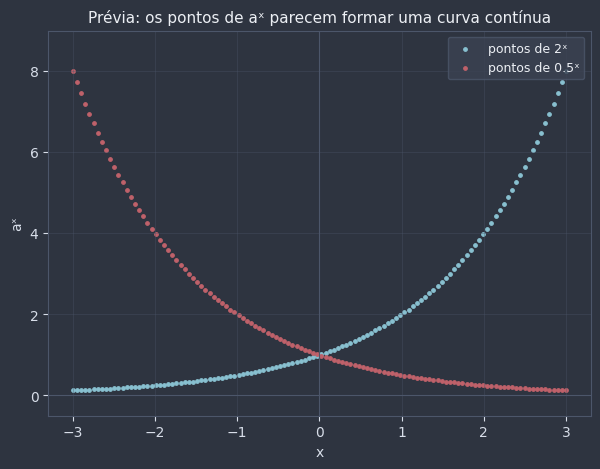

In [14]:
# Prévia: plotando pontos a^x para vários valores reais de x (ainda não é
# "a função", só uma prévia visual de como os pontos se organizam)
xs_previa = np.linspace(-3, 3, 120)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for base_previa, cor in ((2, COR_PONTO), (0.5, COR_ALERTA)):
    ax.scatter(xs_previa, base_previa**xs_previa, s=6, color=cor, label=f"pontos de {base_previa:g}ˣ")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("aˣ", color=NORD_TEXTO_SEC)
ax.set_ylim(-0.5, 9)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_title("Prévia: os pontos de aˣ parecem formar uma curva contínua", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** mexa no slider da base a e observe a "nuvem" de pontos de aˣ mudando de formato — este é o gancho direto para o próximo notebook, Função Exponencial.

In [15]:
def explorar_potencia_real(a: float) -> None:
    xs = np.linspace(-3, 3, 150)
    ys = a**xs

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.scatter(xs, ys, s=8, color=COR_DESTAQUE)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel(f"{a:g}ˣ", color=NORD_TEXTO_SEC)
    ax.set_ylim(-0.5, min(ys.max() * 1.1, 30))
    ax.set_title(f"pontos de {a:g}ˣ, para x real entre -3 e 3", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_potencia_real,
    a=widgets.FloatSlider(value=2.0, min=0.2, max=4.0, step=0.1, description="a:"),
)

interactive(children=(FloatSlider(value=2.0, description='a:', max=4.0, min=0.2), Output()), _dom_classes=('wi…

<function __main__.explorar_potencia_real(a: float) -> None>

**Pergunta de checagem:** o que muda visualmente na "nuvem" de pontos de aˣ quando a > 1, comparado a quando 0 < a < 1?

🎯 **Aplicação prática:** crescimento populacional e juros compostos com capitalização contínua só fazem sentido matematicamente porque aˣ está definida para **todo** x real, não apenas para instantes inteiros de tempo.

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| aⁿ (n natural) | a·a·...·a (n fatores) \| a⁰ = 1 (a≠0) |
| a⁻ⁿ | 1/aⁿ (a≠0) |
| Propriedades de potência | aᵐ·aⁿ=aᵐ⁺ⁿ \| aᵐ/aⁿ=aᵐ⁻ⁿ \| (aᵐ)ⁿ=aᵐ·ⁿ \| (ab)ⁿ=aⁿbⁿ \| (a/b)ⁿ=aⁿ/bⁿ |
| ⁿ√a existe em R se... | n ímpar (qualquer a) OU n par e a ≥ 0 |
| Erro comum | √(x²) = \|x\|, não x |
| Propriedades dos radicais | ⁿ√a·ⁿ√b=ⁿ√(ab) \| ⁿ√a/ⁿ√b=ⁿ√(a/b) \| ᵐ√(ⁿ√a)=ᵐⁿ√a |
| Racionalização | multiplicar por um fator (ou conjugado) que elimina o radical do denominador, sem mudar o valor da fração |
| a^(m/n) | = ⁿ√(aᵐ), definida rigorosamente para a > 0 |
| Base negativa + expoente racional | restrito por convenção a a > 0 — simplificar m/n sem cuidado pode gerar contradição |
| aˣ, x irracional | aproxima-se x por racionais cada vez mais precisos; os valores de a^(aproximação) convergem |
| aˣ, x real (a>0) | está definida para TODO x real — base da função exponencial (próximo notebook) |

## Exercícios

**Básico**
1. Aplique as propriedades de potência para simplificar três expressões numéricas, sem calcular tudo "na mão".
2. Determine, para quatro pares (índice, radicando), se a raiz enésima existe em ℝ.

**Intermediário**
3. Converta duas potências de expoente racional para a notação de radical e calcule seus valores.
4. Racionalize dois denominadores, um deles usando o conjugado.

**Desafio**
5. Generalize a lenda do tabuleiro de xadrez para uma razão diferente de 2.
6. Identifique qual das duas simplificações de (-8)^(2/6) usa uma operação inválida por causa da base negativa.

Gabarito completo com resolução passo a passo em [`0201b_potencias_e_raizes_gabarito.ipynb`](0201b_potencias_e_raizes_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: usando as propriedades de potências (sem multiplicar tudo
# na mão), calcule os valores das três expressões abaixo. Preencha
# resultado_1a, resultado_1b e resultado_1c com os valores numéricos.
# a) 2^3 * 2^4 / 2^5
# b) (3^2)^3
# c) 5^0 + 5^(-2)
resultado_1a = ...
resultado_1b = ...
resultado_1c = ...

print(resultado_1a, resultado_1b, resultado_1c)

In [ ]:
# Verificação
assert resultado_1a == 4, "Tente de novo, revise o passo a: 2^3*2^4/2^5 = 2^(3+4-5) (seção 1 - Propriedades)."
assert resultado_1b == 729, "Tente de novo, revise o passo b: (3^2)^3 = 3^(2*3) (seção 1 - Potência de potência)."
assert resultado_1c == 1.04, "Tente de novo, revise o passo c: 5^0=1 e 5^(-2)=1/25 (seções 1 e 2)."
print("Certo!")

In [ ]:
# Exercício Básico 2: para cada par (índice, radicando) abaixo, diga se a raiz
# enésima existe em R (True/False). Preencha existe_ex2 com uma lista de 4
# booleanos, na mesma ordem dos pares.
pares_ex2 = [(2, 16), (3, -27), (4, -16), (5, -32)]

existe_ex2 = ...

print(existe_ex2)

In [ ]:
# Verificação
assert existe_ex2 == [True, True, False, True], (
    "Tente de novo, revise: raiz de índice PAR só existe em R se o radicando "
    "for >= 0; índice ÍMPAR sempre existe (seção 3 - Raiz Enésima Aritmética)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: converta cada potência de expoente racional para a
# notação de radical equivalente e calcule o valor numérico.
# a) 8^(2/3)
# b) 16^(3/4)
valor_ex3a = ...
valor_ex3b = ...

print(valor_ex3a, valor_ex3b)

In [ ]:
# Verificação
assert abs(valor_ex3a - 4) < 1e-9, "Tente de novo, revise: 8^(2/3) = (∛8)^2 = 2^2 (seção 5 - Potência de Expoente Racional)."
assert abs(valor_ex3b - 8) < 1e-9, "Tente de novo, revise: 16^(3/4) = (⁴√16)^3 = 2^3 (seção 5 - Potência de Expoente Racional)."
print("Certo!")

In [ ]:
# Exercício Intermediário 4: racionalize os denominadores abaixo.
# a) 3/√2 vira c_ex4a * √2, com c_ex4a racional. Preencha c_ex4a.
# b) 1/(√5 - 2) vira √5 + d_ex4b, usando o conjugado. Preencha d_ex4b.
c_ex4a = ...
d_ex4b = ...

print(c_ex4a, d_ex4b)

In [ ]:
# Verificação
assert abs(float(c_ex4a) - 1.5) < 1e-9, (
    "Tente de novo, revise: 3/√2 * (√2/√2) = 3√2/2 = 1,5·√2 (seção 4 - Racionalização)."
)
assert abs(float(d_ex4b) - 2) < 1e-9, (
    "Tente de novo, revise: multiplique por (√5+2)/(√5+2); o denominador vira "
    "5-4=1 (seção 4 - Racionalização com conjugado)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: em vez de DOBRAR a cada casa (razão 2), imagine um
# tabuleiro em que o número de grãos TRIPLICA a cada casa (razão 3), começando
# com 1 grão na primeira casa (3^0). Some os grãos das 10 primeiras casas
# (3^0 até 3^9) usando potências (não multiplique tudo na mão). Preencha
# total_graos_ex5.
total_graos_ex5 = ...

print(total_graos_ex5)

In [ ]:
# Verificação
assert total_graos_ex5 == sum(3**k for k in range(10)), (
    "Tente de novo, revise: some 3^0 + 3^1 + ... + 3^9 usando potências "
    "(seção 1 - Potência de Expoente Natural)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: as duas contas abaixo partem de (-8)^(2/6) mas chegam em
# resultados diferentes (-2 e 2):
#   - simplificar o expoente antes: (-8)^(2/6) = (-8)^(1/3) = -2
#   - elevar a base antes: ((-8)^2)^(1/6) = 64^(1/6) = 2
# Qual das duas usa uma simplificação inválida por causa da base negativa?
# Responda com a string "simplificar_expoente" ou "elevar_primeiro".
resposta_ex6 = ...

print(resposta_ex6)

In [ ]:
# Verificação
assert resposta_ex6 == "simplificar_expoente", (
    "Tente de novo, revise a seção 6 - Restrições: Base Negativa e Expoente "
    "Racional: simplificar a fração do expoente (2/6 -> 1/3) muda qual raiz "
    "está sendo calculada quando a base é negativa, gerando a inconsistência."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Base | o número que está sendo elevado a uma potência (o a em aⁿ) |
| Expoente | o número que indica quantas vezes a base é multiplicada por si mesma (o n em aⁿ) |
| Índice | o número que indica qual raiz está sendo calculada (o n em ⁿ√a) |
| Radicando | o número do qual se extrai a raiz (o a em ⁿ√a) |
| Racionalização | técnica de reescrever uma fração para eliminar radicais do denominador, sem mudar seu valor |


## Conexões

**Isso depende de:**
- [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (potenciação e radiciação básicas, aritmética, Python)

**Isso será usado em:**
- [`0202a_funcao_exponencial.ipynb`](0202a_funcao_exponencial.ipynb) (próximo notebook deste módulo — usa diretamente a ideia de aˣ definida para todo x real)
- [`02_logaritmos/`](.) (mudança de base envolve potências e raízes)
- [`10_matematica_financeira_comercial_e_estatistica_descritiva/`](../10_matematica_financeira_comercial_e_estatistica_descritiva/) (juros compostos)
- [`04_geometria_plana/`](../04_geometria_plana/) e [`06_geometria_espacial/`](../06_geometria_espacial/) (fórmulas com radicais)